In [3]:
pip install scipy

You should consider upgrading via the '/Users/sindhu/Documents/code/ML/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd

# Assuming 'y' is your target variable (the column you want to check for balance)
# For example, if your target variable is in the DataFrame 'X' and is named 'survived':
df = sns.load_dataset("titanic")
df = df.drop(columns=['deck', 'embark_town', 'alive'])  # drop mostly null or duplicate info

# Target
y = df['survived'] # Replace 'survived' with your actual target variable name

# Count the occurrences of each class
class_counts = y.value_counts()

# Print the counts
print("Class distribution:")
print(class_counts)

# Check if the dataset is balanced
# Assuming class_counts is a pandas Series with counts of each class
total_count = class_counts.sum()
class_0_count = class_counts[0]  # Count of the first class (not survived)
class_1_count = class_counts[1]  # Count of the second class (survived)

# Calculate percentages
class_0_percentage = (class_0_count / total_count) * 100
class_1_percentage = (class_1_count / total_count) * 100

# Print the results
print(f"Percentage of class 0 (not survived): {class_0_percentage:.2f}%")
print(f"Percentage of class 1 (survived): {class_1_percentage:.2f}%")

Class distribution:
survived
0    549
1    342
Name: count, dtype: int64
Percentage of class 0 (not survived): 61.62%
Percentage of class 1 (survived): 38.38%


Missing values:
 pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
class           0
who             0
adult_male      0
alone           0
dtype: int64

Data types:
 pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class         category
who             object
adult_male        bool
alone             bool
dtype: object


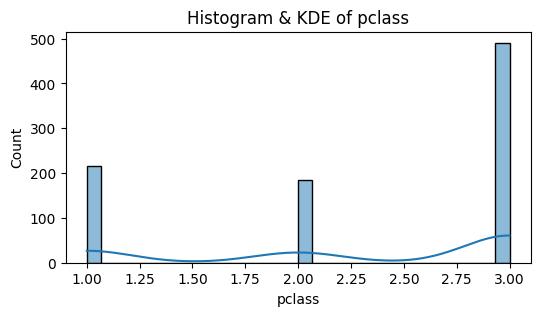

pclass skewness: -0.63


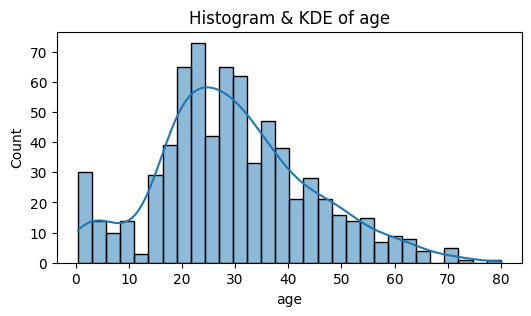

age skewness: 0.39


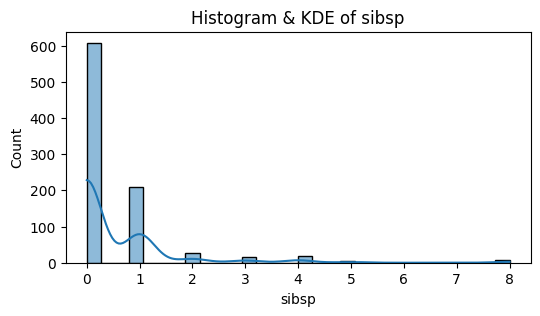

sibsp skewness: 3.70


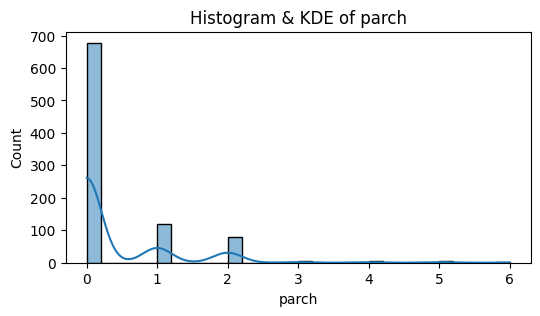

parch skewness: 2.75


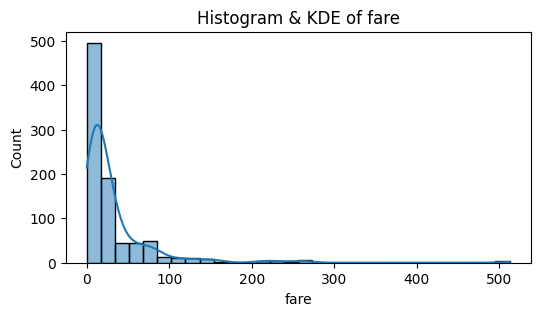

fare skewness: 4.79


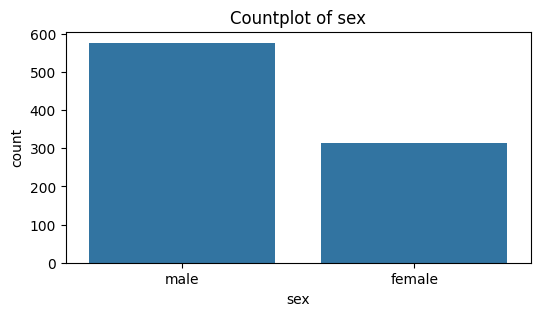

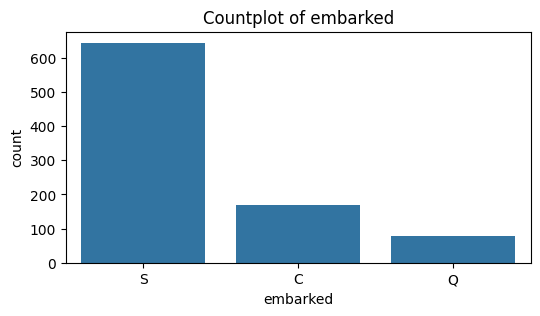

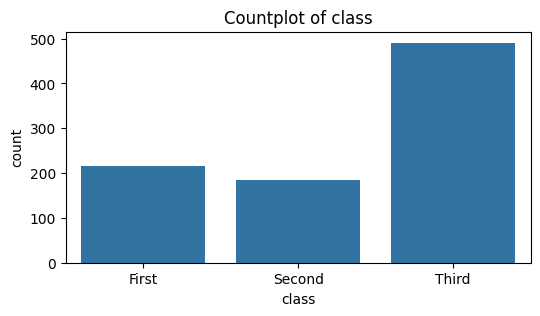

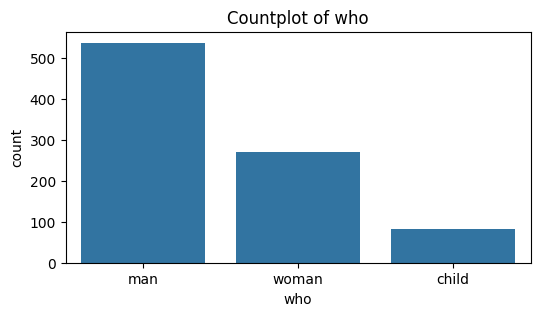

Logistic: Mean CV Accuracy = 0.788
KNN: Mean CV Accuracy = 0.805
RandomForest: Mean CV Accuracy = 0.794
XGBoost: Mean CV Accuracy = 0.785

RandomForest Feature Importance:
         Feature  Importance
4           fare    0.239789
1            age    0.235711
6       sex_male    0.103966
14       who_man    0.089956
5     sex_female    0.074428
2          sibsp    0.052799
15     who_woman    0.047300
0         pclass    0.047175
12   class_Third    0.038700
10   class_First    0.015825
9     embarked_S    0.014793
13     who_child    0.011845
11  class_Second    0.009529
7     embarked_C    0.009342
8     embarked_Q    0.008844
3          parch    0.000000


In [7]:
# ===============================
# Industry-Ready Titanic ML Pipeline with EDA & Preprocessing
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.special import boxcox1p

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -------------------------------
# 1️⃣ Load Data
# -------------------------------
df = sns.load_dataset("titanic")
df = df.drop(columns=['deck', 'embark_town', 'alive'])  # drop mostly null or duplicate info

# Target
y = df['survived']
X = df.drop(columns=['survived'])

# -------------------------------
# 2️⃣ Exploratory Data Analysis (EDA)
# -------------------------------
print("Missing values:\n", X.isnull().sum())
print("\nData types:\n", X.dtypes)

# Visualize numeric features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_features:
    plt.figure(figsize=(6,3))
    sns.histplot(X[col], bins=30, kde=True)
    plt.title(f'Histogram & KDE of {col}')
    plt.show()
    
    skew_val = X[col].skew()
    print(f"{col} skewness: {skew_val:.2f}")

# Visualize categorical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_features:
    plt.figure(figsize=(6,3))
    sns.countplot(data=X, x=col)
    plt.title(f'Countplot of {col}')
    plt.show()

# -------------------------------
# 3️⃣ Train/Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 4️⃣ Preprocessing Pipelines
# -------------------------------

# Numeric preprocessing: impute, handle outliers, skew, scale
def handle_skew_outliers(X_numeric):
    X_numeric = pd.DataFrame(X_numeric, columns=numeric_features)
    X_numeric = X_numeric.copy()
    for col in numeric_features:
        # Outlier capping (1.5*IQR)
        Q1 = X_numeric[col].quantile(0.25)
        Q3 = X_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        X_numeric[col] = np.clip(X_numeric[col], lower, upper)
        
        # Skew correction for |skew| >1
        skew_val = X_numeric[col].skew()
        if skew_val > 1 or skew_val < -1:
            # Box-Cox requires all positive
            X_numeric[col] = boxcox1p(X_numeric[col] - X_numeric[col].min() + 1, 0.15)
    return X_numeric.values

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('skew_outlier', FunctionTransformer(handle_skew_outliers)),
    ('scaler', StandardScaler())
])

# Categorical preprocessing: impute + one-hot encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# -------------------------------
# 5️⃣ Models
# -------------------------------
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# -------------------------------
# 6️⃣ Cross-Validation Pipeline
# -------------------------------
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: Mean CV Accuracy = {scores.mean():.3f}")

# -------------------------------
# 7️⃣ Train & Feature Importance (Optional)
# -------------------------------
# Example for RandomForest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
rf_pipeline.fit(X_train, y_train)

# Get feature names after preprocessing
encoded_cat_features = rf_pipeline.named_steps['preprocessor'] \
                        .named_transformers_['cat'] \
                        .named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = numeric_features + list(encoded_cat_features)

# Feature importances
importances = rf_pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("\nRandomForest Feature Importance:")
print(feature_importance_df)


In [11]:
# ===============================
# Industry-Style Model Evaluation for Titanic
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, roc_auc_score, confusion_matrix, classification_report)

from scipy.special import boxcox1p

# -------------------------------
# 1️⃣ Load Titanic Dataset
# -------------------------------
df = sns.load_dataset("titanic")
df = df.drop(columns=['deck', 'embark_town', 'alive'])  # drop mostly null / duplicate

# Target & features
y = df['survived']
X = df.drop(columns=['survived'])

# -------------------------------
# 2️⃣ Train/Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 3️⃣ Detect numeric & categorical features
# -------------------------------
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# -------------------------------
# 4️⃣ Preprocessing Pipelines
# -------------------------------
def handle_skew_outliers(X_numeric):
    X_numeric = pd.DataFrame(X_numeric, columns=numeric_features)
    for col in numeric_features:
        # Outlier capping (1.5*IQR)
        Q1 = X_numeric[col].quantile(0.25)
        Q3 = X_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        X_numeric[col] = np.clip(X_numeric[col], lower, upper)
        
        # Skew correction if |skew| > 1
        skew_val = X_numeric[col].skew()
        if skew_val > 1 or skew_val < -1:
            # Box-Cox requires positive values
            X_numeric[col] = boxcox1p(X_numeric[col] - X_numeric[col].min() + 1, 0.15)
    return X_numeric.values

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('skew_outlier', FunctionTransformer(handle_skew_outliers)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# -------------------------------
# 5️⃣ Models
# -------------------------------
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# -------------------------------
# 6️⃣ Evaluation Loop
# -------------------------------
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Fit pipeline
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:,1]
    else:
        y_proba = y_pred  # for models without proba
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "ROC-AUC": roc_auc
    })
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name} Confusion Matrix:\n{cm}")
    print(f"\n{name} Classification Report:\n{classification_report(y_test, y_pred)}")

# -------------------------------
# 7️⃣ Summary Table
# -------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False)
print("\nModel Comparison:\n", results_df)



Logistic Confusion Matrix:
[[89 16]
 [19 55]]

Logistic Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179


KNN Confusion Matrix:
[[95 10]
 [19 55]]

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       105
           1       0.85      0.74      0.79        74

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179


RandomForest Confusion Matrix:
[[89 16]
 [16 58]]

RandomForest Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       105

F1-score balances precision and recall:

KNN → 0.791 (highest)

RandomForest → 0.784

Logistic → 0.759

XGBoost → 0.731

Precision (how many predicted survivors are correct)

KNN → 0.846 (best) → very good at avoiding false positives

Recall (how many actual survivors we correctly predicted)

RandomForest → 0.783 → better than KNN’s 0.743

KNN sacrifices recall to gain higher precision


Interpretation:

KNN is conservative: predicts fewer survivors but is mostly correct → higher precision

RandomForest is balanced: slightly lower precision but better recall → fewer missed survivors

Logistic and XGBoost are slightly worse overall in F1/recall

ROC-AUC measures model’s ranking ability, independent of threshold.

RandomForest → 0.891 (highest) → best at distinguishing survivors vs non-survivors

KNN → 0.882 → good but slightly worse

XGBoost & Logistic → ~0.875–0.878 → acceptable but lower

ROC-AUC is considered more robust than accuracy, especially with imbalance.

Interpretability:

Logistic → very interpretable

KNN → not interpretable (hard to explain “distance-based” predictions)

RandomForest / XGBoost → partially interpretable via feature importance

Robustness & Deployment:

KNN: sensitive to scaling, slow for large datasets

RandomForest: robust, handles outliers, generalizes well

XGBoost: robust, but may need hyperparameter tuning

Business Goal:

If maximizing correctly predicting survivors → RandomForest is slightly better (balanced F1 + ROC-AUC + recall)

If maximizing overall correct predictions → KNN looks better by accuracy/F1, but could overfit small dataset

Best model in this scenario: RandomForest

Slightly lower accuracy than KNN (0.821 vs 0.838)

Highest ROC-AUC (0.891) → best at distinguishing survivors vs non-survivors

Balanced F1, precision, recall → not sacrificing recall like KNN

More robust and interpretable for deployment than KNN

KNN could still be used if:

Dataset is small

High precision is more important than recall

You don’t need scalability or interpretability

XGBoost underperforms slightly on all metrics here → maybe needs hyperparameter tuning.

Logistic Regression → interpretable, reasonable performance, good if business wants simple explanation.